In [1]:
%load_ext autoreload
%autoreload 2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import einops
from fancy_einsum import einsum
import os
import tqdm.auto as tqdm
import random
from pathlib import Path
import plotly.express as px
from torch.utils.data import DataLoader

from typing import List, Union, Optional
from functools import partial
import copy

import itertools
from transformers import AutoModelForCausalLM, AutoConfig, AutoTokenizer
import dataclasses
import datasets
from IPython.display import HTML

In [2]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)  # Hooking utilities
from transformer_lens import HookedTransformer, HookedTransformerConfig, FactoredMatrix, ActivationCache


device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
def imshow(tensor, renderer=None, xaxis="", yaxis="", **kwargs):
    px.imshow(utils.to_numpy(tensor), color_continuous_midpoint=0.0, color_continuous_scale="RdBu", labels={"x":xaxis, "y":yaxis}, **kwargs).show(renderer)

def line(tensor, renderer=None, xaxis="", yaxis="", **kwargs):
    px.line(utils.to_numpy(tensor), labels={"x":xaxis, "y":yaxis}, **kwargs).show(renderer)

def scatter(x, y, xaxis="", yaxis="", caxis="", renderer=None, **kwargs):
    x = utils.to_numpy(x)
    y = utils.to_numpy(y)
    px.scatter(y=y, x=x, labels={"x":xaxis, "y":yaxis, "color":caxis}, **kwargs).show(renderer)

In [4]:
p = 113
frac_train = 0.3

# Optimizer config
lr = 1e-3
wd = 1. 
betas = (0.9, 0.98)

num_epochs = 25000
checkpoint_every = 100

DATA_SEED = 598

In [5]:
a_vector = einops.repeat(torch.arange(p), "i -> (i j)", j=p)
b_vector = einops.repeat(torch.arange(p), "j -> (i j)", i=p)
equals_vector = einops.repeat(torch.tensor(113), " -> (i j)", i=p, j=p)

In [6]:
dataset = torch.stack([a_vector, b_vector, equals_vector], dim=1).to(device)
print(dataset[:5])
print(dataset.shape)

tensor([[  0,   0, 113],
        [  0,   1, 113],
        [  0,   2, 113],
        [  0,   3, 113],
        [  0,   4, 113]], device='cuda:0')
torch.Size([12769, 3])


In [7]:
labels = (dataset[:, 0] + dataset[:, 1]) % p
print(labels.shape)
print(labels[:5])

torch.Size([12769])
tensor([0, 1, 2, 3, 4], device='cuda:0')


In [8]:
torch.manual_seed(DATA_SEED)
indices = torch.randperm(p*p)
cutoff = int(p*p*frac_train)
train_indices = indices[:cutoff]
test_indices = indices[cutoff:]

train_data = dataset[train_indices]
train_labels = labels[train_indices]
test_data = dataset[test_indices]
test_labels = labels[test_indices]
print(train_data[:5])
print(train_labels[:5])
print(train_data.shape)
print(test_data[:5])
print(test_labels[:5])
print(test_data.shape)

tensor([[ 21,  31, 113],
        [ 30,  98, 113],
        [ 47,  10, 113],
        [ 86,  21, 113],
        [ 99,  83, 113]], device='cuda:0')
tensor([ 52,  15,  57, 107,  69], device='cuda:0')
torch.Size([3830, 3])
tensor([[ 43,  40, 113],
        [ 31,  42, 113],
        [ 39,  63, 113],
        [ 35,  61, 113],
        [112, 102, 113]], device='cuda:0')
tensor([ 83,  73, 102,  96, 101], device='cuda:0')
torch.Size([8939, 3])


In [9]:

cfg = HookedTransformerConfig(
    n_layers = 1,
    n_heads = 4,
    d_model = 128,
    d_head = 32,
    d_mlp = 512,
    act_fn = "relu",
    normalization_type=None,
    d_vocab=p+1,
    d_vocab_out=p,
    n_ctx=3,
    init_weights=True,
    device=device,
    seed = 999,
)

In [10]:
model = HookedTransformer(cfg)

In [11]:
for name, param in model.named_parameters():
    if "b_" in name:
        param.requires_grad = False


In [12]:
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd, betas=betas)

In [13]:
def loss_fn(logits, labels):
    if len(logits.shape)==3:
        logits = logits[:, -1]
    logits = logits.to(torch.float64)
    log_probs = logits.log_softmax(dim=-1)
    correct_log_probs = log_probs.gather(dim=-1, index=labels[:, None])[:, 0]
    return -correct_log_probs.mean()
train_logits = model(train_data)
train_loss = loss_fn(train_logits, train_labels)
print(train_loss)
test_logits = model(test_data)
test_loss = loss_fn(test_logits, test_labels)
print(test_loss)

tensor(4.7359, device='cuda:0', dtype=torch.float64, grad_fn=<NegBackward0>)
tensor(4.7330, device='cuda:0', dtype=torch.float64, grad_fn=<NegBackward0>)


In [14]:
print("Uniform loss:")
print(np.log(p))

Uniform loss:
4.727387818712341


In [16]:
train_losses = []
test_losses = []
model_checkpoints = []
checkpoint_epochs = []
TRAIN_MODEL = True
if TRAIN_MODEL:
    for epoch in tqdm.tqdm(range(num_epochs)):
        train_logits = model(train_data)
        train_loss = loss_fn(train_logits, train_labels)
        train_loss.backward()
        train_losses.append(train_loss.item())

        optimizer.step()
        optimizer.zero_grad()

        with torch.inference_mode():
            test_logits = model(test_data)
            test_loss = loss_fn(test_logits, test_labels)
            test_losses.append(test_loss.item())
        
        if ((epoch+1)%checkpoint_every)==0:
            checkpoint_epochs.append(epoch)
            model_checkpoints.append(copy.deepcopy(model.state_dict()))
            print(f"Epoch {epoch} Train Loss {train_loss.item()} Test Loss {test_loss.item()}")

  0%|          | 0/25000 [00:00<?, ?it/s]

Epoch 99 Train Loss 2.9215491232253994 Test Loss 7.651618460718301
Epoch 199 Train Loss 0.029663325230822542 Test Loss 19.993823332650134
Epoch 299 Train Loss 0.009387394824136685 Test Loss 20.642669157951392
Epoch 399 Train Loss 0.0030181850470389114 Test Loss 21.781239926007384
Epoch 499 Train Loss 0.0009980540447164434 Test Loss 23.008660605845765
Epoch 599 Train Loss 0.00033615007909670836 Test Loss 24.28864897871053
Epoch 699 Train Loss 0.00011468073409210167 Test Loss 25.576526349769278
Epoch 799 Train Loss 3.973434687293156e-05 Test Loss 26.84086742313692
Epoch 899 Train Loss 1.4071527163272051e-05 Test Loss 28.073119007862317
Epoch 999 Train Loss 5.1861934085308375e-06 Test Loss 29.223143757687005
Epoch 1099 Train Loss 2.0731102997163683e-06 Test Loss 30.22547371907725
Epoch 1199 Train Loss 9.606098610927324e-07 Test Loss 31.013985815956147
Epoch 1299 Train Loss 5.516786274134859e-07 Test Loss 31.470159903865028
Epoch 1399 Train Loss 4.0174420269144426e-07 Test Loss 31.57543823

In [17]:
original_logits, cache = model.run_with_cache(dataset)
print(original_logits.numel())

4328691


In [18]:
W_E = model.embed.W_E[:-1]
print("W_E", W_E.shape)
W_neur = W_E @ model.blocks[0].attn.W_V @ model.blocks[0].attn.W_O @ model.blocks[0].mlp.W_in
print("W_neur", W_neur.shape)
W_logit = model.blocks[0].mlp.W_out @ model.unembed.W_U
print("W_logit", W_logit.shape)

W_E torch.Size([113, 128])
W_neur torch.Size([4, 113, 512])
W_logit torch.Size([512, 113])


In [19]:
original_loss = loss_fn(original_logits, labels).item()
print("Original Loss:", original_loss)

Original Loss: 3.6681230177688906e-07


In [20]:
pattern_a = cache["pattern", 0, "attn"][:, :, -1, 0]
pattern_b = cache["pattern", 0, "attn"][:, :, -1, 1]
neuron_acts = cache["post", 0, "mlp"][:, -1, :]
neuron_pre_acts = cache["pre", 0, "mlp"][:, -1, :]

In [21]:
for param_name, param in cache.items():
    print(param_name, param.shape)

hook_embed torch.Size([12769, 3, 128])
hook_pos_embed torch.Size([12769, 3, 128])
blocks.0.hook_resid_pre torch.Size([12769, 3, 128])
blocks.0.attn.hook_q torch.Size([12769, 3, 4, 32])
blocks.0.attn.hook_k torch.Size([12769, 3, 4, 32])
blocks.0.attn.hook_v torch.Size([12769, 3, 4, 32])
blocks.0.attn.hook_attn_scores torch.Size([12769, 4, 3, 3])
blocks.0.attn.hook_pattern torch.Size([12769, 4, 3, 3])
blocks.0.attn.hook_z torch.Size([12769, 3, 4, 32])
blocks.0.hook_attn_out torch.Size([12769, 3, 128])
blocks.0.hook_resid_mid torch.Size([12769, 3, 128])
blocks.0.mlp.hook_pre torch.Size([12769, 3, 512])
blocks.0.mlp.hook_post torch.Size([12769, 3, 512])
blocks.0.hook_mlp_out torch.Size([12769, 3, 128])
blocks.0.hook_resid_post torch.Size([12769, 3, 128])


In [22]:
imshow(cache["pattern", 0].mean(dim=0)[:, -1, :], title="Average Attention Pattern per Head", xaxis="Source", yaxis="Head", x=['a', 'b', '='])

In [23]:
imshow(cache["pattern", 0][5][:, -1, :], title="Average Attention Pattern per Head", xaxis="Source", yaxis="Head", x=['a', 'b', '='])

In [24]:
cache["post", 0, "mlp"].shape

torch.Size([12769, 3, 512])

In [25]:
imshow(
    einops.rearrange(neuron_acts[:, :5], "(a b) neuron -> neuron a b", a=p, b=p), 
    title="First 5 neuron acts", xaxis="b", yaxis="a", facet_col=0)

In [26]:
U, S, Vh = torch.svd(W_E)
line(S, title="Singular Values")
imshow(U, title="Principal Components on the Input")

In [27]:
# Control - random Gaussian matrix
U, S, Vh = torch.svd(torch.randn_like(W_E))
line(S, title="Singular Values Random")
imshow(U, title="Principal Components Random")

In [28]:
U, S, Vh = torch.svd(W_E)
line(U[:, :8].T, title="Principal Components of the embedding", xaxis="Input Vocabulary")

In [29]:
fourier_basis = []
fourier_basis_names = []
fourier_basis.append(torch.ones(p))
fourier_basis_names.append("Constant")
for freq in range(1, p//2+1):
    fourier_basis.append(torch.sin(torch.arange(p)*2 * torch.pi * freq / p))
    fourier_basis_names.append(f"Sin {freq}")
    fourier_basis.append(torch.cos(torch.arange(p)*2 * torch.pi * freq / p))
    fourier_basis_names.append(f"Cos {freq}")
fourier_basis = torch.stack(fourier_basis, dim=0).to(device)
fourier_basis = fourier_basis/fourier_basis.norm(dim=-1, keepdim=True)
imshow(fourier_basis, xaxis="Input", yaxis="Component", y=fourier_basis_names)

In [36]:
!uv pip install git+https://github.com/neelnanda-io/neel-plotly.git 
from neel_plotly.plot import line
line([train_losses[::100], test_losses[::100]], x=np.arange(0, len(train_losses), 100), xaxis="Epoch", yaxis="Loss", log_y=True, title="Training Curve for Modular Addition", line_labels=['train', 'test'], toggle_x=True, toggle_y=True)

Using Python 3.12.3 environment at: /home/omar-ayyub/p/FeatureManifolds/.venv
Resolved 37 packages in 40ms                                         
Audited 37 packages in 0.06ms


In [37]:
U, S, Vh = torch.svd(W_E)
line(U[:, :8].T, title="Principal Components of the embedding", xaxis="Input Vocabulary")

In [38]:
fourier_basis = []
fourier_basis_names = []
fourier_basis.append(torch.ones(p))
fourier_basis_names.append("Constant")
for freq in range(1, p//2+1):
    fourier_basis.append(torch.sin(torch.arange(p)*2 * torch.pi * freq / p))
    fourier_basis_names.append(f"Sin {freq}")
    fourier_basis.append(torch.cos(torch.arange(p)*2 * torch.pi * freq / p))
    fourier_basis_names.append(f"Cos {freq}")
fourier_basis = torch.stack(fourier_basis, dim=0).to(device)
fourier_basis = fourier_basis/fourier_basis.norm(dim=-1, keepdim=True)
imshow(fourier_basis, xaxis="Input", yaxis="Component", y=fourier_basis_names)

In [39]:
line(fourier_basis[:8], xaxis="Input", line_labels=fourier_basis_names[:8], title="First 8 Fourier Components")
line(fourier_basis[25:29], xaxis="Input", line_labels=fourier_basis_names[25:29], title="Middle Fourier Components")

In [40]:
imshow(fourier_basis @ fourier_basis.T, title="All Fourier Vectors are Orthogonal")

In [41]:
imshow(fourier_basis @ W_E, yaxis="Fourier Component", xaxis="Residual Stream", y=fourier_basis_names, title="Embedding in Fourier Basis")

In [42]:
line((fourier_basis @ W_E).norm(dim=-1), xaxis="Fourier Component", x=fourier_basis_names, title="Norms of Embedding in Fourier Basis")

In [43]:
key_freqs = [17, 25, 32, 47]
key_freq_indices = [33, 34, 49, 50, 63, 64, 93, 94]
fourier_embed = fourier_basis @ W_E
key_fourier_embed = fourier_embed[key_freq_indices]
print("key_fourier_embed", key_fourier_embed.shape)
imshow(key_fourier_embed @ key_fourier_embed.T, title="Dot Product of embedding of key Fourier Terms")

key_fourier_embed torch.Size([8, 128])


In [44]:
logits, cache = model.run_with_cache(dataset)
mlp_acts = cache["blocks.0.mlp.hook_post"]

In [47]:
last_acts = mlp_acts[:,-1,:]

In [49]:
#import sklearn pca
from sklearn.decomposition import PCA

pca = PCA()
#fit transform
pca.fit(last_acts.detach().cpu().numpy())
pca_results = pca.transform(last_acts.detach().cpu().numpy())

#plot explained variance ratio
line(pca.explained_variance_ratio_[:10], xaxis="Principal Component", yaxis="Explained Variance Ratio", title="Explained Variance Ratio of MLP Output")

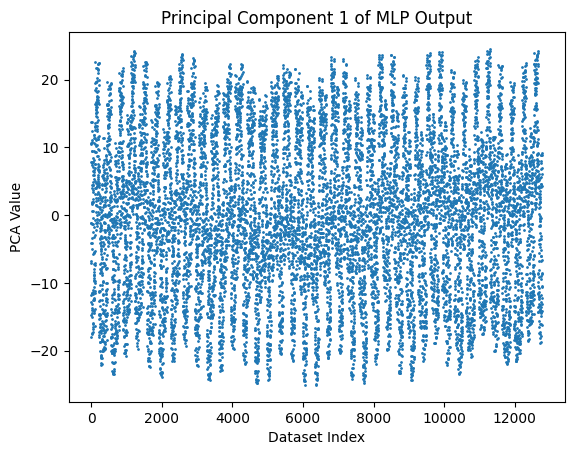

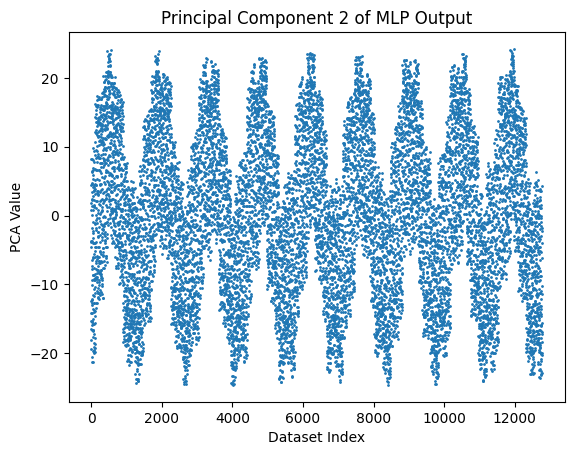

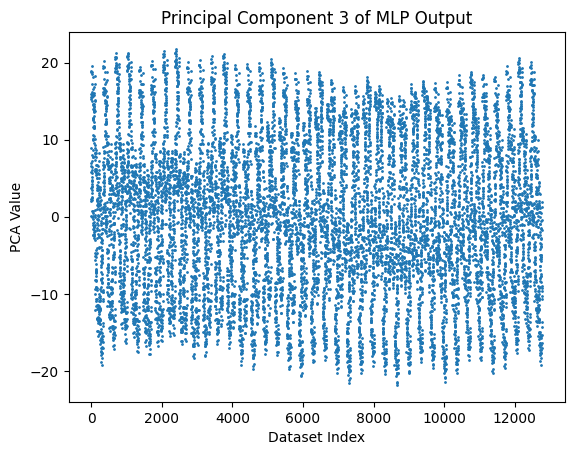

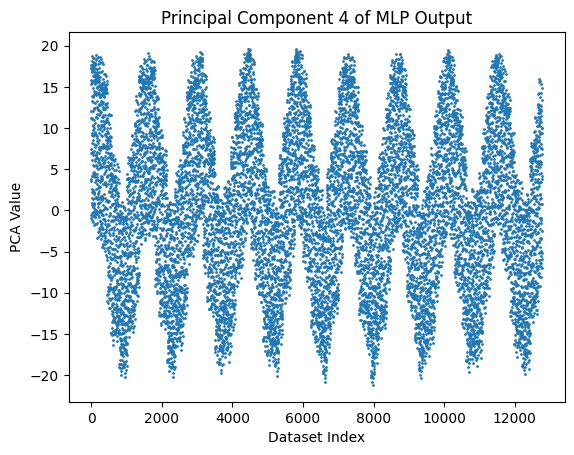

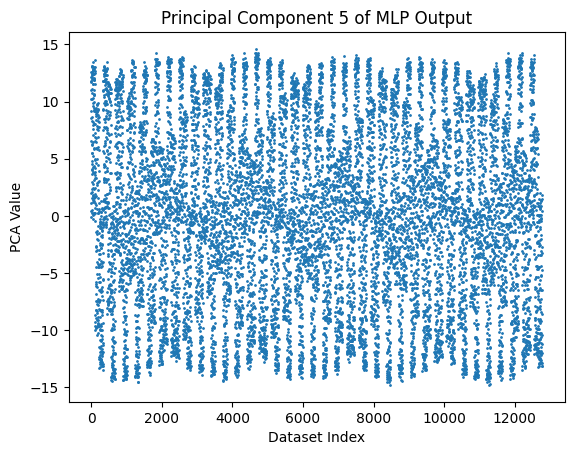

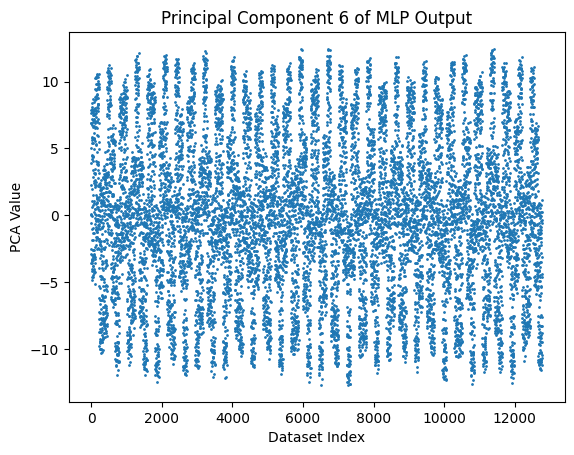

In [56]:
#plot each of the first 6 principal components against dataset length using matplotlib
import matplotlib.pyplot as plt
for i in range(6):
    plt.figure()
    plt.scatter(np.arange(len(last_acts)), pca_results[:, i], s=1)
    plt.title(f"Principal Component {i+1} of MLP Output")
    plt.xlabel("Dataset Index")
    plt.ylabel("PCA Value")
    plt.show()
    plt.close()

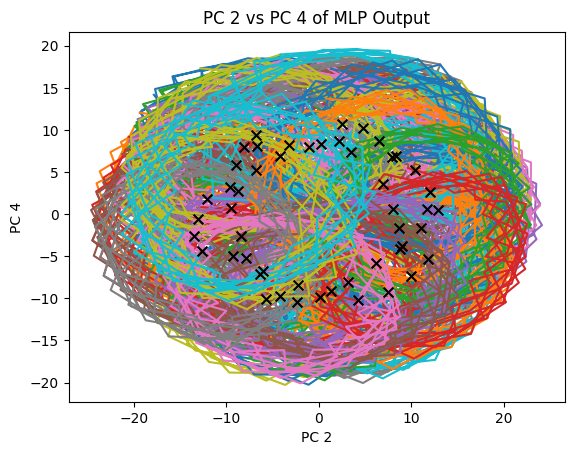

In [76]:
#plot PC 2 vs PC 4
plt.figure()
for a in range(50):
    plt.plot(pca_results[:, 1][a*113:a*113+113], pca_results[:, 3][a*113:a*113+113])
    #plot centroid
    centroid_x = pca_results[:, 1][a*113:a*113+113].mean()
    centroid_y = pca_results[:, 3][a*113:a*113+113].mean()
    plt.scatter(centroid_x, centroid_y, s=50, marker='x', color='black', zorder=22)

plt.title("PC 2 vs PC 4 of MLP Output")
plt.xlabel("PC 2")
plt.ylabel("PC 4")
plt.show()